# Desafio - Análise de Dados e Storytelling

## Definição do Problema

Este projeto tem como objetivo analisar a incidência de casos de dengue no estado de São Paulo entre os anos de 2013 e 2023.

A análise busca identificar padrões, tendências ao longo do tempo e possíveis períodos de surtos, utilizando técnicas de análise de dados e visualização.

A partir disso, serão gerados insights que possam contribuir para a compreensão do comportamento da doença e apoiar possíveis ações de prevenção.

## Explorando Dataset



In [1]:
# Bibliotecas para manipulação e análise de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização de dados
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [6]:
# Lê o arquivo Excel e armazena no DataFrame df_dengue
df_dengue = pd.read_excel('/content/sample_data/Base de Dados Dengue.xlsx')

# Exibe as primeiras 5 linhas do DataFrame (índice começa em 0)
df_dengue.head()

,municipio,uf,data_infeccoes,qtd_infeccoes
0,ALTA FLORESTA D'OESTE,RO,2013-01-01,34
1,ALTA FLORESTA D'OESTE,RO,2013-02-01,44
2,ALTA FLORESTA D'OESTE,RO,2013-03-01,15
3,ALTA FLORESTA D'OESTE,RO,2013-04-01,4
4,ALTA FLORESTA D'OESTE,RO,2013-05-01,3


In [7]:
# Ajusta o formato da data
df_dengue['data_infeccoes'] = pd.to_datetime(df_dengue['data_infeccoes'])

# Verifica os tipos
df_dengue.dtypes

,0
municipio,object
uf,object
data_infeccoes,datetime64[ns]
qtd_infeccoes,int64


In [8]:
# Cria coluna com o ano
df_dengue['ano'] = df_dengue['data_infeccoes'].dt.year

# Visualiza para conferir
df_dengue.head()

,municipio,uf,data_infeccoes,qtd_infeccoes,ano
0,ALTA FLORESTA D'OESTE,RO,2013-01-01,34,2013
1,ALTA FLORESTA D'OESTE,RO,2013-02-01,44,2013
2,ALTA FLORESTA D'OESTE,RO,2013-03-01,15,2013
3,ALTA FLORESTA D'OESTE,RO,2013-04-01,4,2013
4,ALTA FLORESTA D'OESTE,RO,2013-05-01,3,2013


In [9]:
# Filtra apenas os dados do estado de São Paulo (SP)
df_sp = df_dengue.loc[df_dengue['uf'] == 'SP']

# Visualiza
df_sp.head()

,municipio,uf,data_infeccoes,qtd_infeccoes,ano
430584,ADAMANTINA,SP,2013-01-01,10,2013
430585,ADAMANTINA,SP,2013-02-01,61,2013
430586,ADAMANTINA,SP,2013-03-01,173,2013
430587,ADAMANTINA,SP,2013-04-01,32,2013
430588,ADAMANTINA,SP,2013-05-01,20,2013


In [13]:
df_sp['uf'].unique()

array(['SP'], dtype=object)

In [12]:
# Verifica os anos disponíveis em SP
df_sp['ano'].unique()

array([2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
      dtype=int32)

In [14]:
# Agrupa os dados por ano e calcula o total de casos de dengue no estado de São Paulo
casos_por_ano_sp = df_sp.groupby('ano')['qtd_infeccoes'].sum().reset_index()

# Visualiza
casos_por_ano_sp

,ano,qtd_infeccoes
0,2013,121219
1,2014,109342
2,2015,286000
3,2016,77559
4,2017,5038
5,2018,10098
6,2019,178852
7,2020,109705
8,2021,105707
9,2022,177043


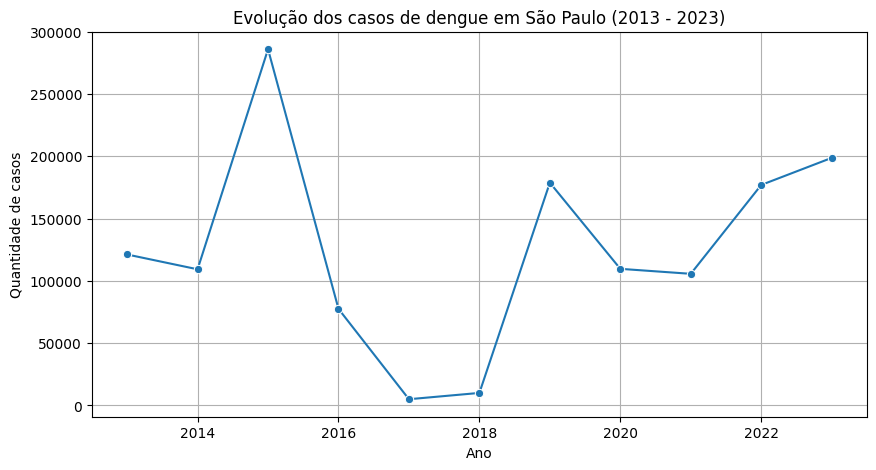

In [15]:
# Cria um gráfico de linha para visualizar a evolução dos casos ao longo dos anos em SP
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=casos_por_ano_sp,
    x='ano',
    y='qtd_infeccoes',
    marker='o'
)

# Títulos
plt.title('Evolução dos casos de dengue em São Paulo (2013 - 2023)')
plt.xlabel('Ano')
plt.ylabel('Quantidade de casos')

plt.grid(True)

plt.show()